# Dask quickstart — `DatasetCollection`

A time-series of co-registered rasters as one lazy 4-D `(T, B, R, C)` cube. Workers reopen
each file on demand — a `gdal.Dataset` handle never crosses the pickle boundary. For the
full surface (`groupby`, metadata snapshots, kerchunk) see `lazy-collection-complete`.

## Setup

In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np

DATA = Path('../../../examples/data')
DATA.is_dir()

True

## Build a cube from a folder of rasters

In [2]:
from pyramids.dataset import DatasetCollection

files = sorted((DATA / 'crop_aligned_folder').glob('[0-5].tif'))
cube = DatasetCollection.from_files(files)
cube.time_length, cube.rows, cube.columns

(6, 24, 29)

`cube` stacks six co-registered rasters. We plot the first timestep (`iloc(0)`) to see one
slice of the 4-D cube the lazy reductions run over.

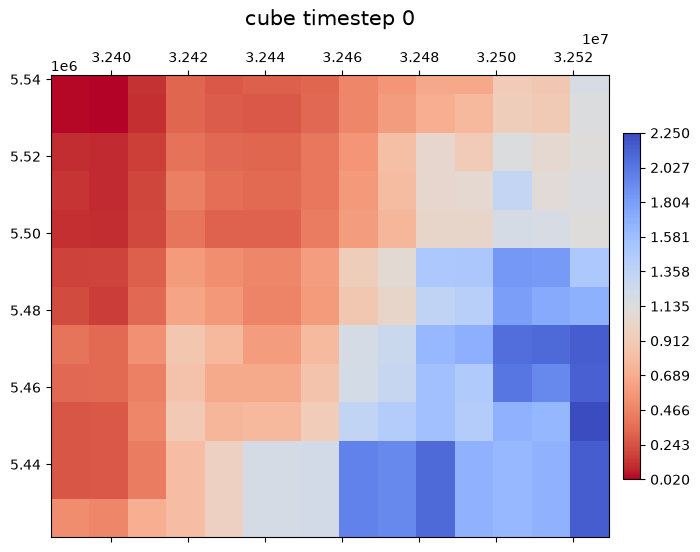

In [3]:
cube.iloc(0).plot(band=0, title="cube timestep 0")

## The lazy 4-D cube — `collection.data`

In [4]:
# One chunk per timestep by default: the delayed graph reads a whole file at a time.
cube.data.shape, cube.data.chunks

((6, 1, 24, 29), ((1, 1, 1, 1, 1, 1), (1,), (24,), (29,)))

## Time-axis reductions

In [5]:
stats = {
    'mean': float(cube.mean(skipna=True).mean()),
    'min': float(cube.min().min()),
    'max': float(cube.max().max()),
    'std': float(cube.std().mean()),
}
stats

{'mean': 0.6656417846679688,
 'min': 0.0,
 'max': 5.150000095367432,
 'std': 1.144860863685608}

## Grouped reductions — `groupby(labels)`

Pass one label per timestep; each group reduces to its own array. With the `[lazy]` extra
installed, one lazy dask reduction per group is evaluated in a single `dask.compute`.

In [6]:
labels = np.array(['A', 'A', 'A', 'B', 'B', 'B'][: cube.time_length])
group_means = cube.groupby(labels).mean()
sorted(group_means), group_means['A'].shape

([np.str_('A'), np.str_('B')], (1, 24, 29))

## Parallel cube write — `to_zarr`

In [7]:
import tempfile

store = Path(tempfile.mkdtemp(prefix='pyramids-cube-')) / 'cube.zarr'
cube.to_zarr(store, mode='w')
sorted(p.name for p in store.iterdir())[:5]

['data', 'spatial_ref', 'x', 'y', 'zarr.json']

## Where to next

Three tiers for `DatasetCollection` + Dask:

- **Complete cookbook (offline)** —
  [Lazy `DatasetCollection`](../dataset/lazy-collection-complete.ipynb): `groupby`,
  picklable metadata snapshots, cube-to-Zarr.
- **Cloud (live data)** — the temporal-stack section of
  [Dask on Sentinel-2 COGs (AWS)](../dataset/dask-lazy-datasets.ipynb).
- **Narrative guide** —
  the [Lazy collections tutorial](../../tutorials/lazy/lazy-collection.md).
- **All classes at a glance** — [the overview](overview.ipynb).